Polynomial Regression Equation: Target = 2.57 + (-2.40 * Feature^1) + (1.68 * Feature^2)
Mean Squared Error: 0.061708741217467514
R^2 Score: 0.9999803224677241


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


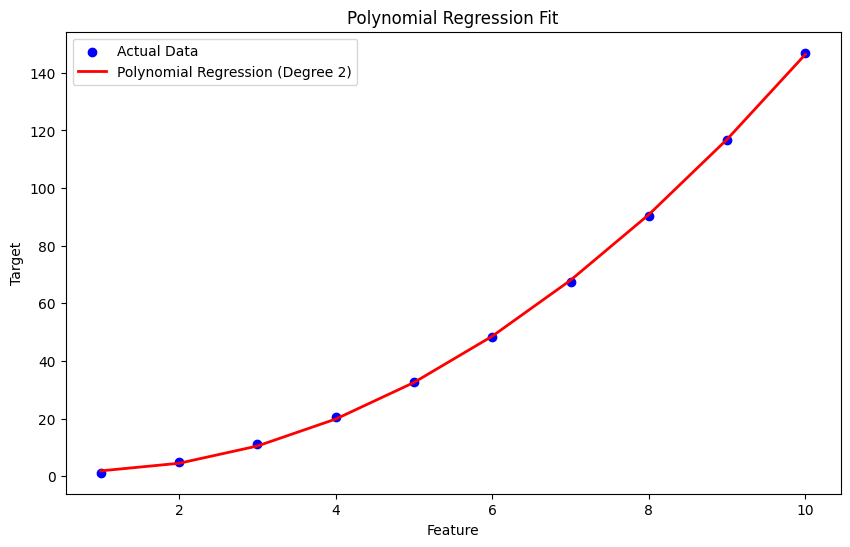

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample dataset
data = {
    'Feature': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Target': [1.2, 4.8, 11.3, 20.5, 32.6, 48.2, 67.5, 90.3, 116.8, 147.0]
}

df = pd.DataFrame(data)

# Splitting dataset into features and target
X = df[['Feature']]
y = df['Target']

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transforming data for polynomial regression
degree = 2  # Change degree as needed
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Creating and training the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Making predictions
y_pred = model.predict(X_test_poly)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Regression equation
coefficients = model.coef_
intercept = model.intercept_
equation = f"Target = {intercept:.2f} + " + " + ".join([f"({coeff:.2f} * Feature^{i})" for i, coeff in enumerate(coefficients) if i > 0])

# Display results
print("Polynomial Regression Equation:", equation)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# Visualization
plt.figure(figsize=(10, 6))
X_sorted = np.sort(X, axis=0)
y_sorted_pred = model.predict(poly.transform(X_sorted))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_sorted, y_sorted_pred, color='red', linewidth=2, label=f'Polynomial Regression (Degree {degree})')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()
